# The AI Learning Curve: An Analysis of the Anthropic Economic Index

**Framing**: Augmentation (collaborative interaction) predicts task success,
and this mechanism underlies the tenure/learning curve effect in AI-assisted work.

**Data**: Release 2026-03-24 (conversations sampled February 5–12, 2026)
- Claude.ai (Free, Pro, Max): ~1M conversations
- First-party API: ~1M records

**Source**: [Anthropic/EconomicIndex on HuggingFace](https://huggingface.co/datasets/Anthropic/EconomicIndex)

This notebook performs analysis directly on the published dataset. All numbers are
computed from the data, not copied from reports. Published figures are referenced
for cross-validation where applicable.

## 1. Setup & Data Loading

Load all four datasets and verify basic structure.

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from pathlib import Path

from src import style
from src.data import (
    load_claude_ai, load_api, load_job_exposure, load_task_penetration,
    get_global_stats, get_collaboration_split,
    get_top_tasks, get_request_categories,
    get_task_collaboration, get_task_success_rates,
    get_country_usage, get_us_state_usage,
    get_task_education, get_task_time, get_task_autonomy,
    query_facet, AUGMENTATION_MODES, AUTOMATION_MODES,
)

# Configure display
pd.set_option('display.max_columns', None)

# Apply project styling
style.apply()
FIG_DIR = Path("../figures")
FIG_DIR.mkdir(exist_ok=True)

# Load all four datasets
cai = load_claude_ai()
api = load_api()
jobs = load_job_exposure()
tasks = load_task_penetration()

print("Dataset shapes:")
print(f"  Claude.ai:        {cai.shape} ({len(cai):,} rows)")
print(f"  1P API:           {api.shape} ({len(api):,} rows)")
print(f"  Job exposure:     {jobs.shape}")
print(f"  Task penetration: {tasks.shape}")


Dataset shapes:
  Claude.ai:        (425257, 10) (425,257 rows)
  1P API:           (195156, 10) (195,156 rows)
  Job exposure:     (756, 3)
  Task penetration: (17998, 3)


## 2. Global Summary Statistics

Key metrics for both platforms: augmentation/automation shares, success rates,
education requirements, time estimates, and speed improvements.

In [2]:
cai_stats = get_global_stats(cai)
api_stats = get_global_stats(api)

summary = pd.DataFrame({
    "Claude.ai": cai_stats,
    "1P API": api_stats,
}).round(2)

print("\n=== GLOBAL SUMMARY STATISTICS ===\n")
display(summary)

# Print some key highlights
print("\nKey observations:")
print(f"  Augmentation (Claude.ai): {cai_stats['augmentation_pct']:.1f}%")
print(f"  Augmentation (1P API):    {api_stats['augmentation_pct']:.1f}%")
print(f"  Task success (Claude.ai): {cai_stats['task_success_pct']:.1f}%")
print(f"  Task success (1P API):    {api_stats['task_success_pct']:.1f}%")



=== GLOBAL SUMMARY STATISTICS ===



,Claude.ai,1P API
education_years_mean,11.92,13.22
education_years_median,12.00,14.00
ai_autonomy_mean,3.41,2.69
human_only_time_mean,3.06,1.74
human_only_time_median,1.50,0.50
human_with_ai_time_mean,14.30,4.20
human_with_ai_time_median,10.00,2.00
task_success_pct,69.94,50.55
use_case_coursework_pct,12.44,5.67
use_case_personal_pct,42.29,20.14



Key observations:
  Augmentation (Claude.ai): 52.8%
  Augmentation (1P API):    17.2%
  Task success (Claude.ai): 69.9%
  Task success (1P API):    50.5%


## 3. Collaboration Modes: Augmentation vs Automation

Five distinct modes of human-AI collaboration:
- **Augmentation**: task iteration, learning, validation (human retains primacy)
- **Automation**: directive, feedback loop (AI is primacy; human supervises)
- **None**: no clear collaboration pattern

This stacked bar chart shows the breakdown for Claude.ai vs 1P API.

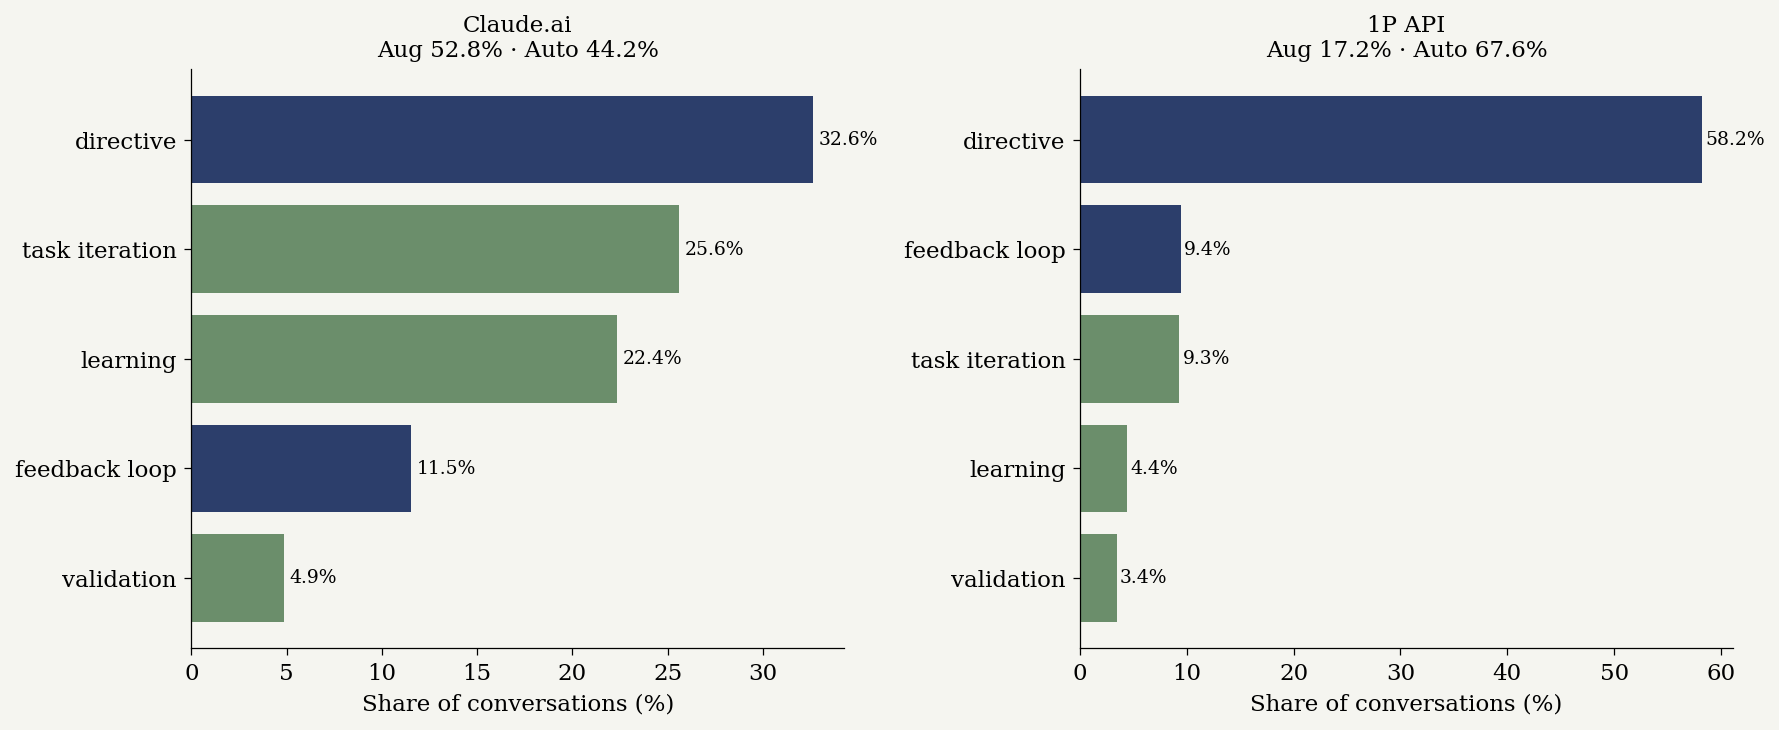

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (df, label) in zip(axes, [(cai, "Claude.ai"), (api, "1P API")]):
    split = get_collaboration_split(df)
    detail = split["detail"].copy()
    detail = detail[detail["mode"] != "none"]
    detail["group"] = detail["mode"].apply(
        lambda m: "Augmentation" if m in AUGMENTATION_MODES else "Automation"
    )
    detail = detail.sort_values("pct", ascending=True)

    colors = [style.NAVY if g == "Automation" else style.SAGE
              for g in detail["group"]]
    ax.barh(detail["mode"], detail["pct"], color=colors)
    ax.set_xlabel("Share of conversations (%)")
    ax.set_title(f"{label}\nAug {split['augmentation_pct']:.1f}% · "
                 f"Auto {split['automation_pct']:.1f}%", fontsize=11)
    for i, (_, row) in enumerate(detail.iterrows()):
        ax.text(row["pct"] + 0.3, i, f"{row['pct']:.1f}%", va="center", fontsize=9)

plt.tight_layout()
fig.savefig(FIG_DIR / "01_collaboration_modes.png", dpi=150, bbox_inches='tight')
plt.show()


## 4. Use Case Distribution

Conversations span three primary contexts: work, personal, and coursework.
API conversations are heavily skewed toward production/work, while Claude.ai
spans all three.

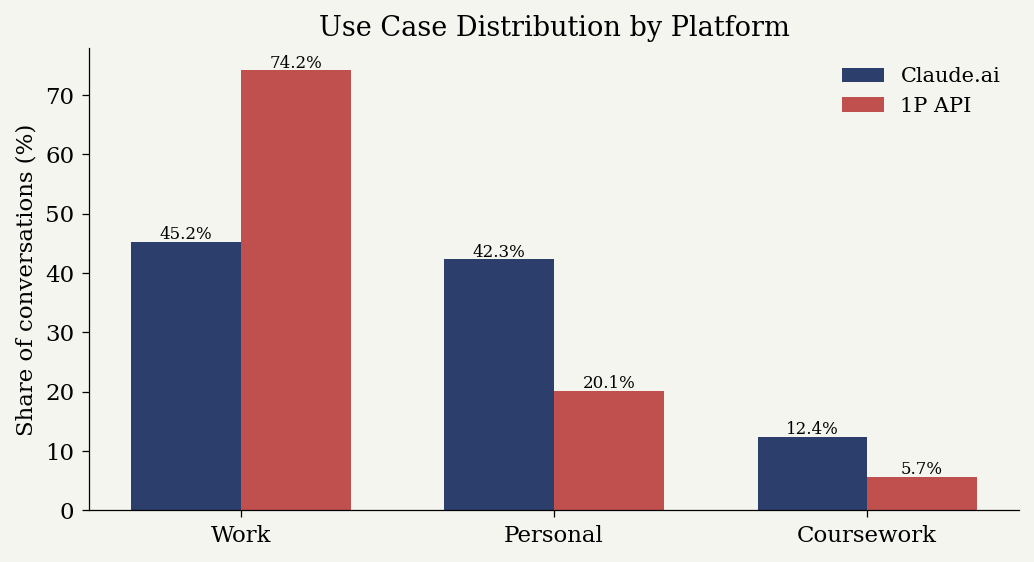

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))

use_cases = ["work", "personal", "coursework"]
cai_vals = [cai_stats[f"use_case_{uc}_pct"] for uc in use_cases]
api_vals = [api_stats[f"use_case_{uc}_pct"] for uc in use_cases]

x = np.arange(len(use_cases))
w = 0.35
ax.bar(x - w/2, cai_vals, w, label="Claude.ai", color=style.NAVY)
ax.bar(x + w/2, api_vals, w, label="1P API", color=style.CLAY)
ax.set_xticks(x)
ax.set_xticklabels([uc.title() for uc in use_cases])
ax.set_ylabel("Share of conversations (%)")
ax.set_title("Use Case Distribution by Platform")
ax.legend()

for i, (cv, av) in enumerate(zip(cai_vals, api_vals)):
    ax.text(i - w/2, cv + 0.5, f"{cv:.1f}%", ha="center", fontsize=8)
    ax.text(i + w/2, av + 0.5, f"{av:.1f}%", ha="center", fontsize=8)

fig.savefig(FIG_DIR / "02_use_case_distribution.png", dpi=150, bbox_inches='tight')
plt.show()


## 5. Request Categories (Occupational Domains)

Level-2 request categories provide the broadest view of task/conversation
domain. This taxonomy reflects the diversity of work across the economy.

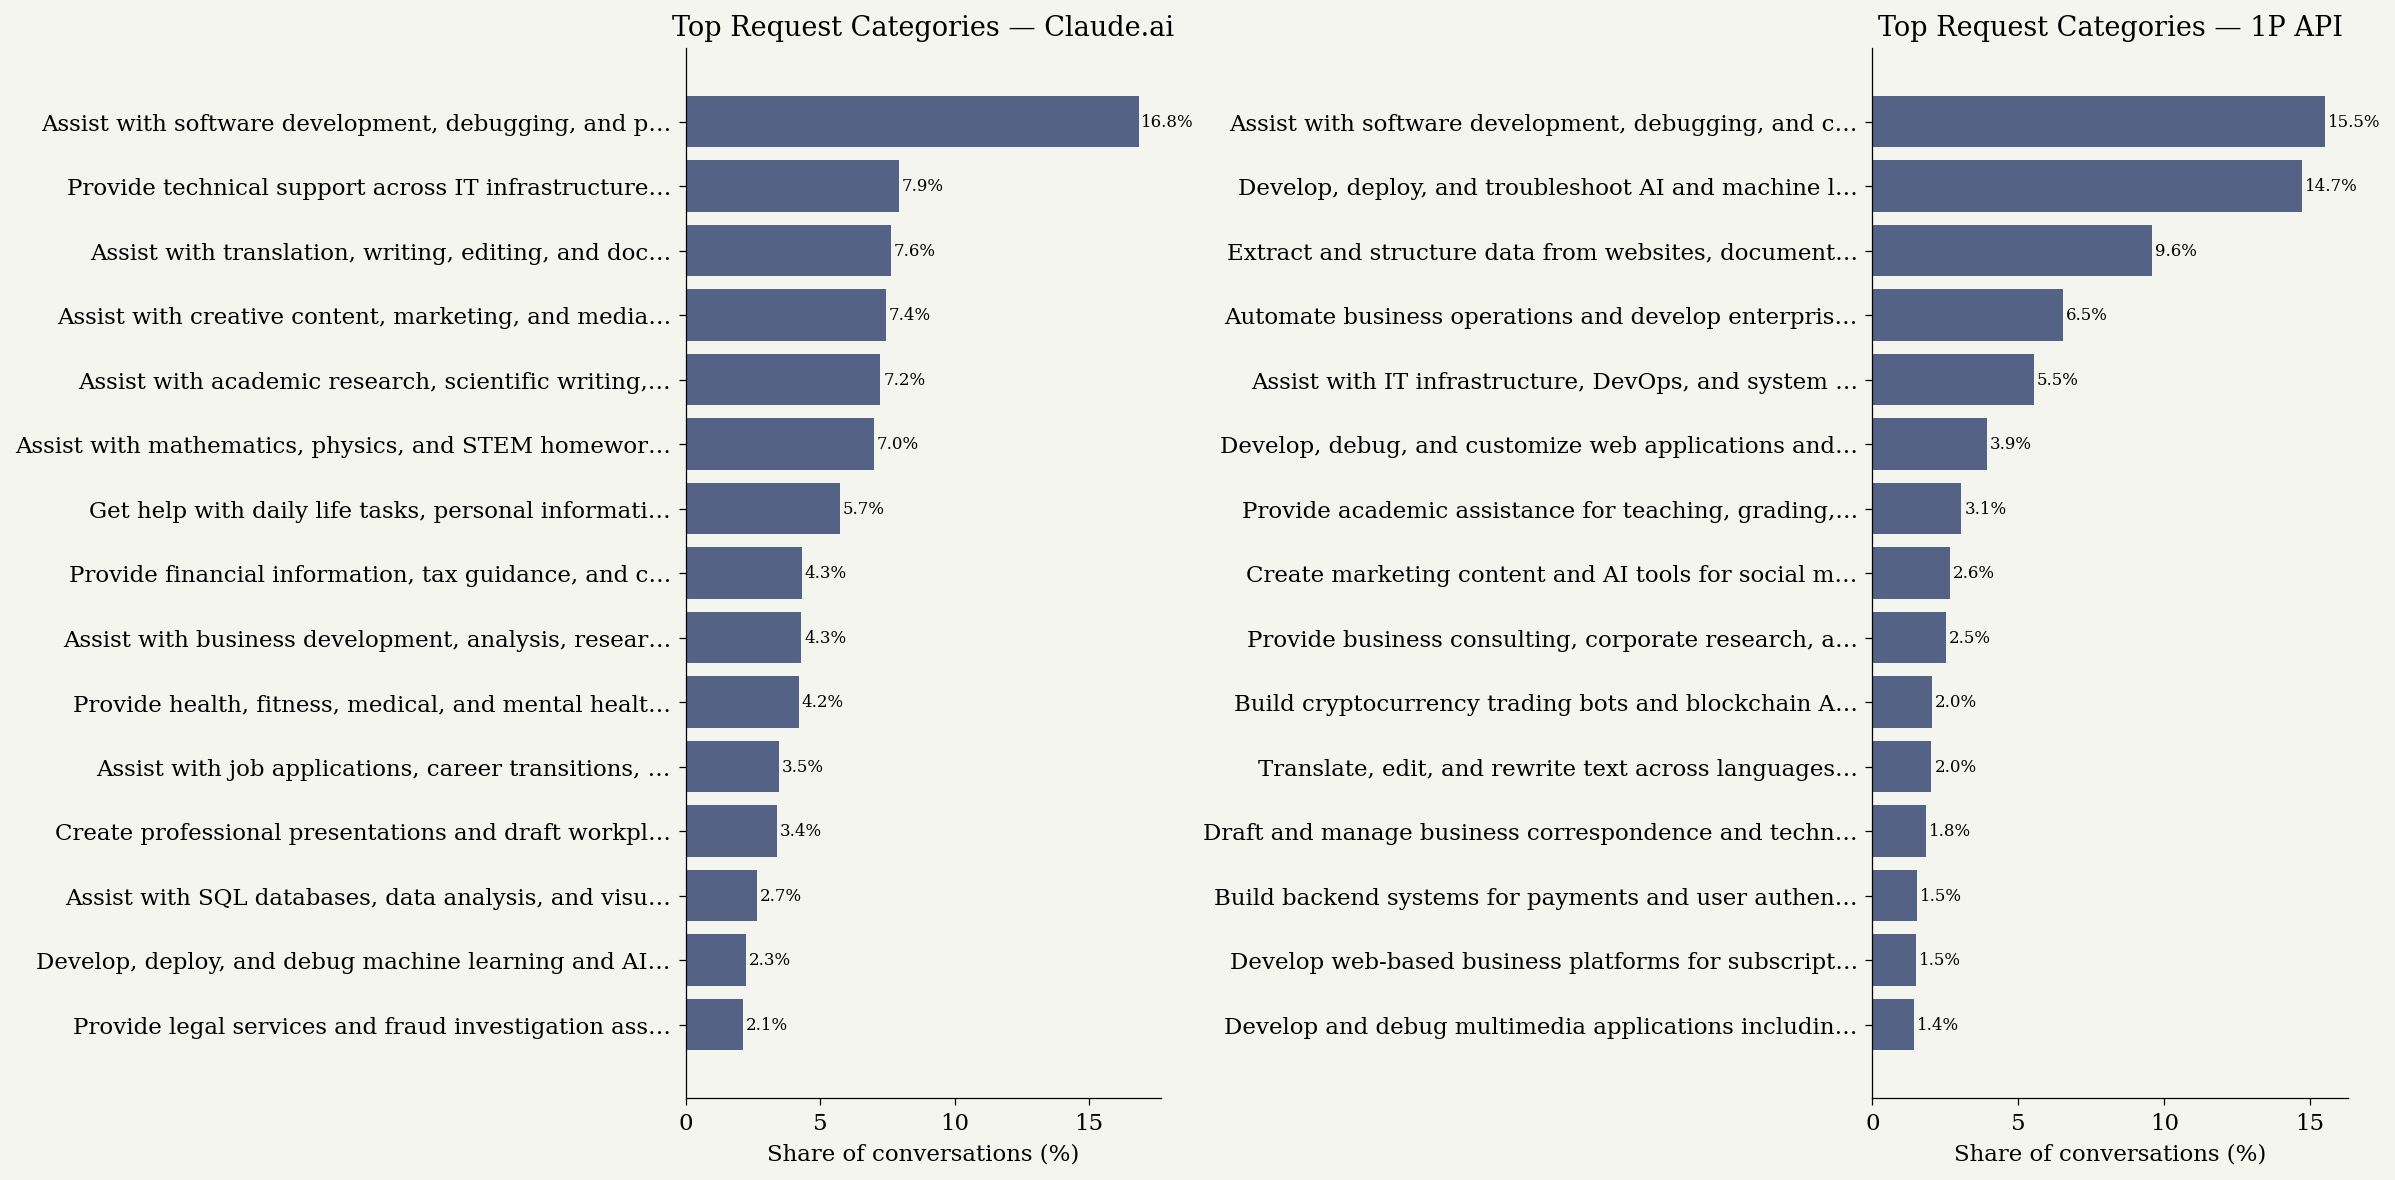

In [5]:
cai_req = get_request_categories(cai, level=2)
api_req = get_request_categories(api, level=2)

# Shorten labels for readability
def shorten(s, n=50):
    return s[:n] + "…" if len(s) > n else s

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

for ax, (req, label) in zip(axes, [(cai_req.head(15), "Claude.ai"),
                                    (api_req.head(15), "1P API")]):
    req = req.copy()
    req["short"] = req["category"].apply(lambda s: shorten(s, 50))
    req = req.sort_values("pct")
    ax.barh(req["short"], req["pct"], color=style.NAVY, alpha=0.8)
    ax.set_xlabel("Share of conversations (%)")
    ax.set_title(f"Top Request Categories — {label}")
    for i, (_, row) in enumerate(req.iterrows()):
        ax.text(row["pct"] + 0.1, i, f"{row['pct']:.1f}%", va="center", fontsize=8)

plt.tight_layout()
fig.savefig(FIG_DIR / "03_request_categories.png", dpi=150, bbox_inches='tight')
plt.show()


## 6. Task Success Rates

Success rates vary significantly by task. Tasks requiring augmentation
(human-AI collaboration) show different success patterns than automated tasks.

This chart shows the top 15 tasks by volume, colored by success rate,
highlighting which tasks benefit most from AI assistance.

Overall success rate:
  Claude.ai: 69.9%
  1P API:    50.5%



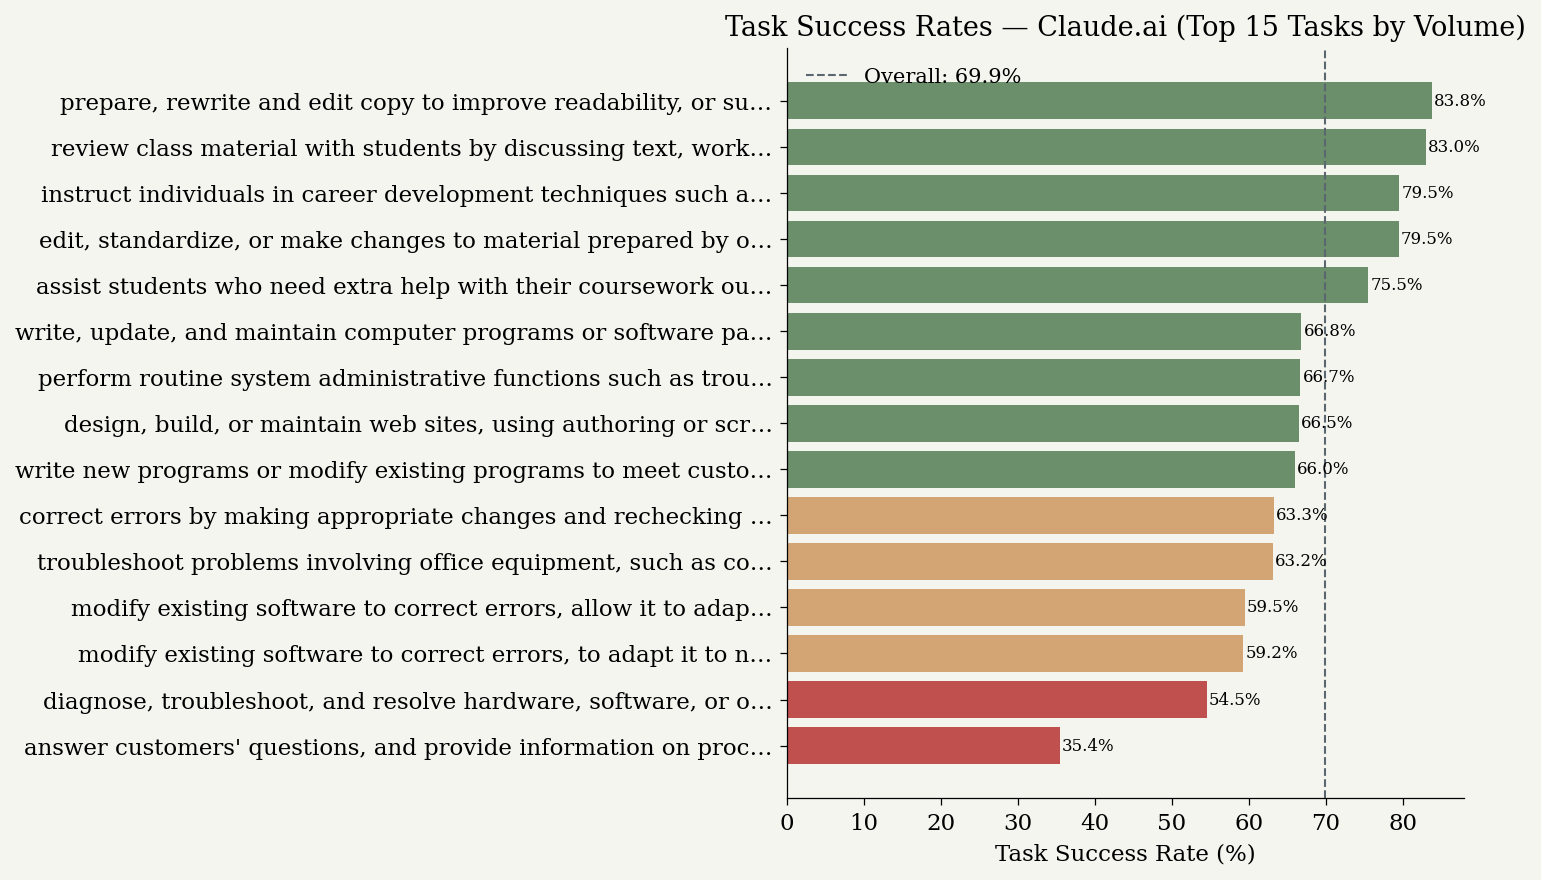

In [6]:
print(f"Overall success rate:")
print(f"  Claude.ai: {cai_stats['task_success_pct']:.1f}%")
print(f"  1P API:    {api_stats['task_success_pct']:.1f}%\n")

# Per-task success rates for Claude.ai
cai_success = get_task_success_rates(cai, n=15)
cai_top = get_top_tasks(cai, n=15)
cai_success = cai_success.merge(cai_top, on="task")

fig, ax = plt.subplots(figsize=(10, 6))
cai_success = cai_success.sort_values("success_pct")
colors = [style.SAGE if s > 65 else style.CLAY if s < 55 else style.SAND
          for s in cai_success["success_pct"]]

def task_short(t, n=60):
    return t[:n] + "…" if len(t) > n else t

ax.barh([task_short(t) for t in cai_success["task"]], cai_success["success_pct"],
        color=colors)
ax.axvline(cai_stats["task_success_pct"], color=style.SLATE, ls="--", lw=1,
           label=f"Overall: {cai_stats['task_success_pct']:.1f}%")
ax.set_xlabel("Task Success Rate (%)")
ax.set_title("Task Success Rates — Claude.ai (Top 15 Tasks by Volume)")
ax.legend()

for i, (_, row) in enumerate(cai_success.iterrows()):
    ax.text(row["success_pct"] + 0.3, i, f"{row['success_pct']:.1f}%",
            va="center", fontsize=8)

plt.tight_layout()
fig.savefig(FIG_DIR / "04_task_success_rates.png", dpi=150, bbox_inches='tight')
plt.show()


## 7. Education Requirements: AI vs Broader Workforce

The dataset includes estimated years of education required for each task's
human component. We compare the AI-weighted distribution against typical
workforce education levels.

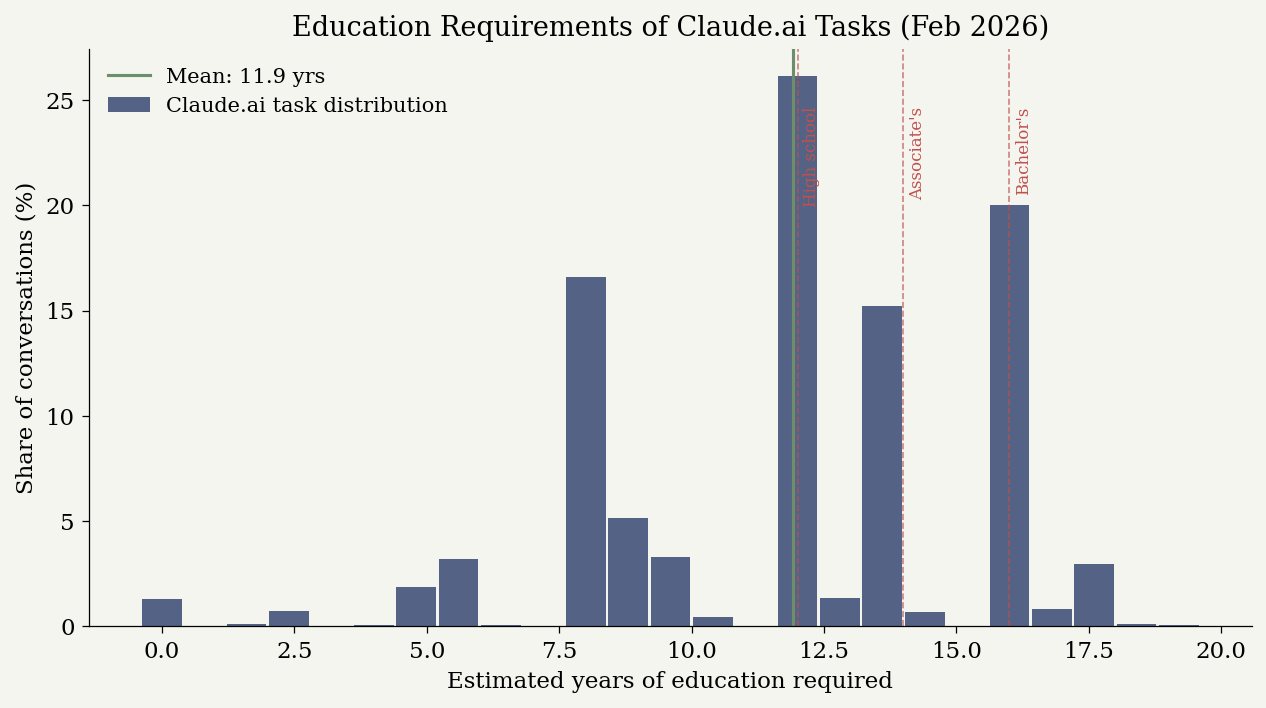


Mean education years:
  Claude.ai tasks: 11.92 yrs
  API tasks:       13.22 yrs


In [7]:
# Education histogram from the data
ed_hist = query_facet(cai, "human_education_years", "human_education_years_histogram_pct", "global")
ed_hist = ed_hist[["cluster_name", "value"]].copy()
# Parse bin edges
ed_hist["bin_lower"] = ed_hist["cluster_name"].str.extract(r"\[([\d.]+)")[0].astype(float)
ed_hist = ed_hist.sort_values("bin_lower")

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(ed_hist["bin_lower"], ed_hist["value"], width=0.75,
       color=style.NAVY, alpha=0.8, label="Claude.ai task distribution")

# Mark key thresholds
for yrs, label in [(12, "High school"), (14, "Associate's"), (16, "Bachelor's")]:
    ax.axvline(yrs, color=style.CLAY, ls="--", lw=0.8, alpha=0.7)
    ax.text(yrs + 0.1, ax.get_ylim()[1] * 0.9, label, fontsize=8,
            color=style.CLAY, rotation=90, va="top")

ax.axvline(cai_stats["education_years_mean"], color=style.SAGE, ls="-", lw=1.5,
           label=f"Mean: {cai_stats['education_years_mean']:.1f} yrs")
ax.set_xlabel("Estimated years of education required")
ax.set_ylabel("Share of conversations (%)")
ax.set_title("Education Requirements of Claude.ai Tasks (Feb 2026)")
ax.legend()

fig.savefig(FIG_DIR / "05_education_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"\nMean education years:")
print(f"  Claude.ai tasks: {cai_stats['education_years_mean']:.2f} yrs")
print(f"  API tasks:       {api_stats['education_years_mean']:.2f} yrs")


## 8. Task Complexity: Time and AI Autonomy

Human-only time (hours) and AI autonomy (1-5 scale) give two complementary
views of task complexity. The speedup metric reveals how AI assistance reduces
task completion time.

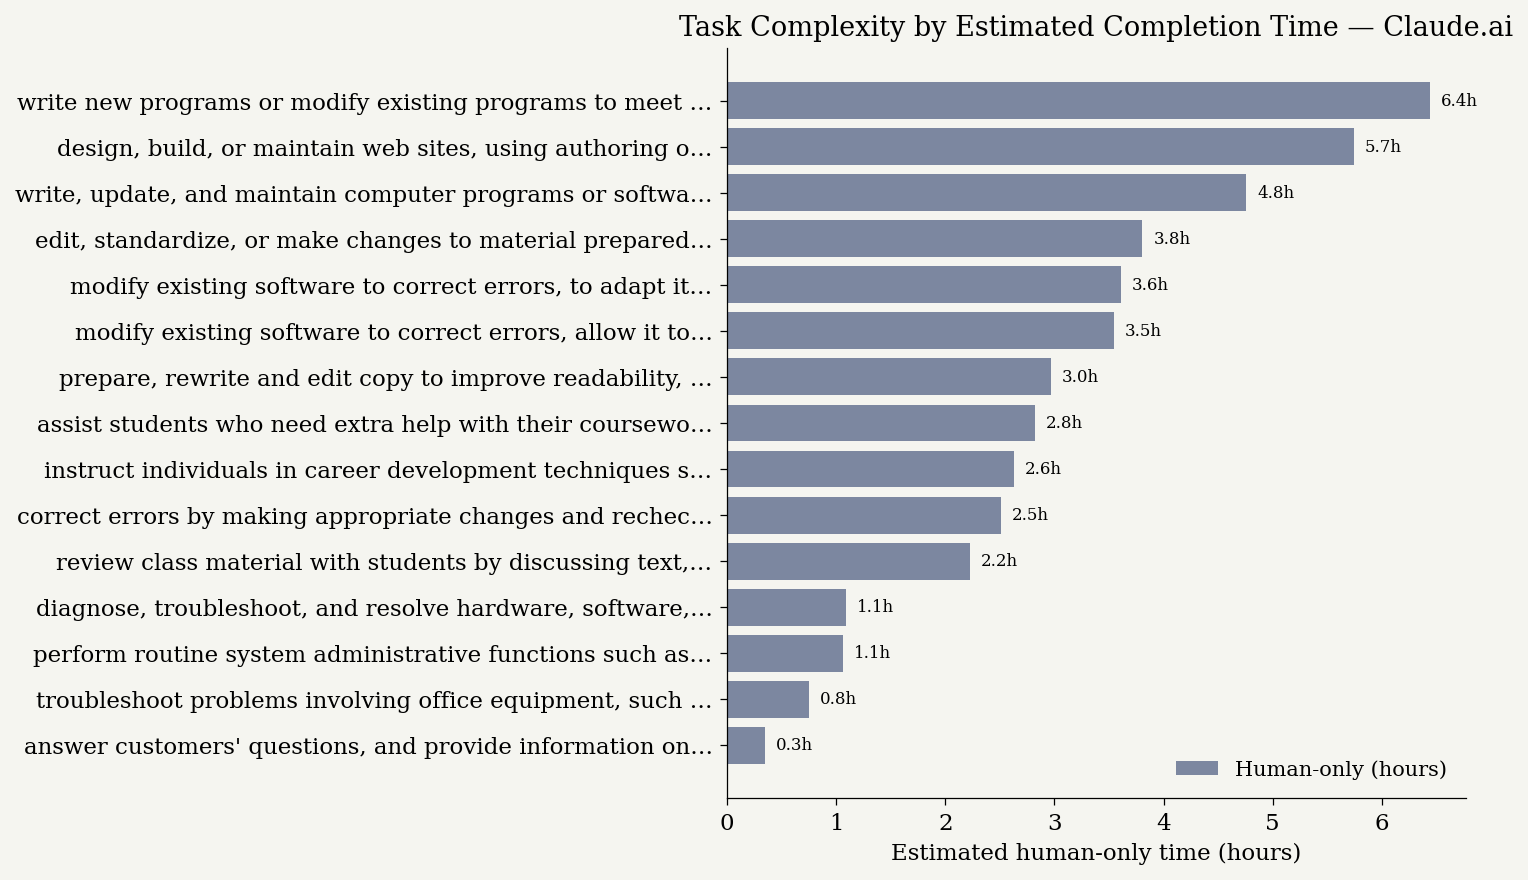


Global time averages:
  Human-only time:
    Claude.ai: 3.06 hrs (median 1.50)
    API:       1.74 hrs (median 0.50)
  Human+AI time:
    Claude.ai: 14.3 min (median 10.0)
    API:       4.2 min (median 2.0)
  Implied speedup:
    Claude.ai: 12.8x
    API:       24.9x


In [8]:
# Time per task
cai_time = get_task_time(cai, n=15)
cai_time["speedup"] = cai_time["human_only_time"] / (cai_time["human_with_ai_time"] / 60)

fig, ax = plt.subplots(figsize=(10, 6))
cai_time = cai_time.sort_values("human_only_time", ascending=True)

ax.barh([task_short(t, 55) for t in cai_time["task"]],
        cai_time["human_only_time"], color=style.NAVY, alpha=0.6,
        label="Human-only (hours)")

ax.set_xlabel("Estimated human-only time (hours)")
ax.set_title("Task Complexity by Estimated Completion Time — Claude.ai")
ax.legend()

for i, (_, row) in enumerate(cai_time.iterrows()):
    ax.text(row["human_only_time"] + 0.1, i, f"{row['human_only_time']:.1f}h",
            va="center", fontsize=8)

plt.tight_layout()
fig.savefig(FIG_DIR / "06_task_complexity_time.png", dpi=150, bbox_inches='tight')
plt.show()

# Global stats
print(f"\nGlobal time averages:")
print(f"  Human-only time:")
print(f"    Claude.ai: {cai_stats['human_only_time_mean']:.2f} hrs (median {cai_stats['human_only_time_median']:.2f})")
print(f"    API:       {api_stats['human_only_time_mean']:.2f} hrs (median {api_stats['human_only_time_median']:.2f})")
print(f"  Human+AI time:")
print(f"    Claude.ai: {cai_stats['human_with_ai_time_mean']:.1f} min (median {cai_stats['human_with_ai_time_median']:.1f})")
print(f"    API:       {api_stats['human_with_ai_time_mean']:.1f} min (median {api_stats['human_with_ai_time_median']:.1f})")
print(f"  Implied speedup:")
print(f"    Claude.ai: {cai_stats['human_only_time_mean'] * 60 / cai_stats['human_with_ai_time_mean']:.1f}x")
print(f"    API:       {api_stats['human_only_time_mean'] * 60 / api_stats['human_with_ai_time_mean']:.1f}x")


## 9. Geographic Distribution: Concentration and Inequality

Country-level usage reveals significant geographic concentration. We compute
the Gini coefficient to quantify inequality in global AI access and usage.

Top 20 countries and top 15 US states are shown alongside concentration metrics.

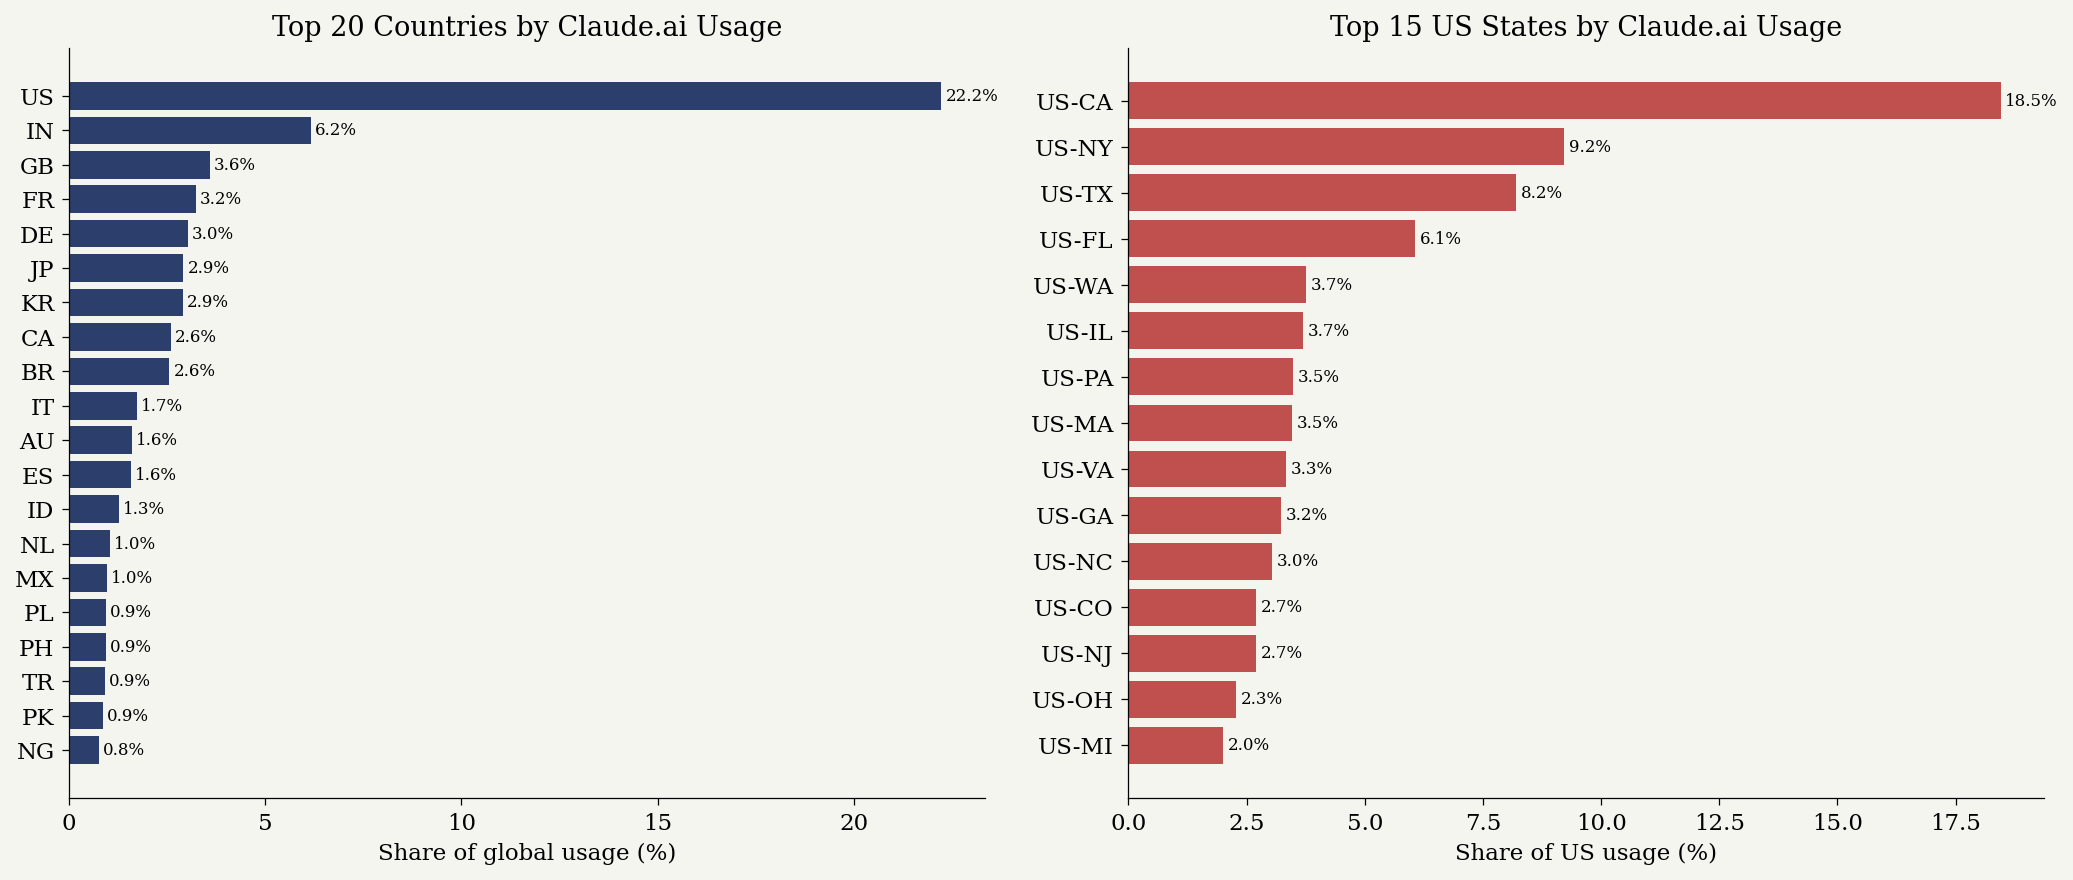


=== CONCENTRATION METRICS ===

Geographic concentration:
  Top 5 countries: 38.2% of global usage
  Top 20 countries: 61.8%
  Total countries with data: 177

US concentration:
  Top 5 states: 45.7% of US usage
  Total states/territories: 54

Geographic inequality (Gini coefficient): 0.835
  Interpretation: 0 = perfect equality, 1 = perfect inequality
  83.5% concentration indicates moderately unequal global distribution.


In [9]:
countries = get_country_usage(cai)
states = get_us_state_usage(cai)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Top countries
top_c = countries.head(20).sort_values("usage_pct")
axes[0].barh(top_c["country"], top_c["usage_pct"], color=style.NAVY)
axes[0].set_xlabel("Share of global usage (%)")
axes[0].set_title("Top 20 Countries by Claude.ai Usage")
for i, (_, row) in enumerate(top_c.iterrows()):
    axes[0].text(row["usage_pct"] + 0.1, i, f"{row['usage_pct']:.1f}%",
                 va="center", fontsize=8)

# Top US states
top_s = states.head(15).sort_values("usage_pct")
axes[1].barh(top_s["state"], top_s["usage_pct"], color=style.CLAY)
axes[1].set_xlabel("Share of US usage (%)")
axes[1].set_title("Top 15 US States by Claude.ai Usage")
for i, (_, row) in enumerate(top_s.iterrows()):
    axes[1].text(row["usage_pct"] + 0.1, i, f"{row['usage_pct']:.1f}%",
                 va="center", fontsize=8)

plt.tight_layout()
fig.savefig(FIG_DIR / "07_geographic_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

# Concentration metrics and Gini coefficient
top5_country_share = countries.head(5)["usage_pct"].sum()
top20_country_share = countries.head(20)["usage_pct"].sum()
top5_state_share = states.head(5)["usage_pct"].sum()

print(f"\n=== CONCENTRATION METRICS ===\n")
print(f"Geographic concentration:")
print(f"  Top 5 countries: {top5_country_share:.1f}% of global usage")
print(f"  Top 20 countries: {top20_country_share:.1f}%")
print(f"  Total countries with data: {len(countries)}")
print(f"\nUS concentration:")
print(f"  Top 5 states: {top5_state_share:.1f}% of US usage")
print(f"  Total states/territories: {len(states)}")

# Compute Gini coefficient
usage_vals = np.sort(countries["usage_pct"].values)
n = len(usage_vals)
# Gini = (2 * sum(i * x_i) - (n+1) * sum(x_i)) / (n * sum(x_i))
gini = (2 * np.sum((np.arange(1, n+1)) * usage_vals) - (n+1) * np.sum(usage_vals)) / (n * np.sum(usage_vals))

print(f"\nGeographic inequality (Gini coefficient): {gini:.3f}")
print(f"  Interpretation: 0 = perfect equality, 1 = perfect inequality")
print(f"  {gini:.1%} concentration indicates moderately unequal global distribution.")
